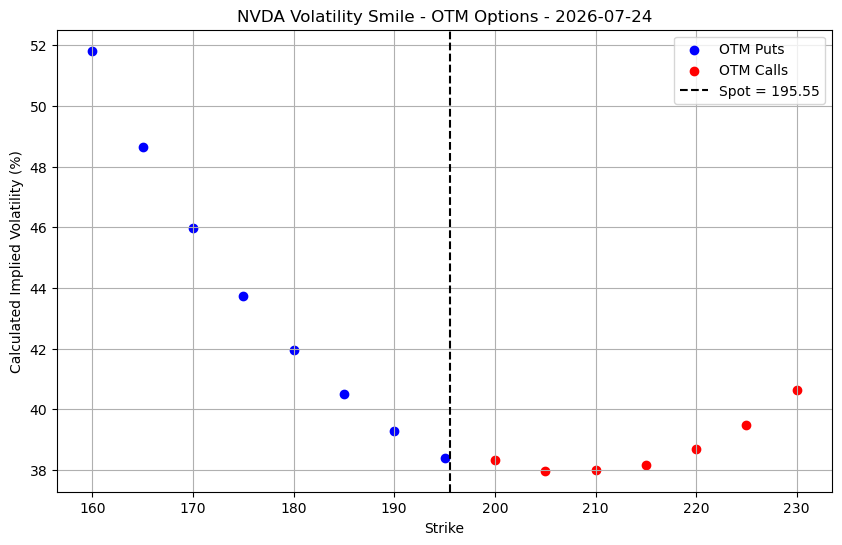

,contractSymbol,option_type,strike,bid,ask,mid,spread_pct,openInterest,iv_calculated_pct,moneyness
0,NVDA260724P00160000,put,160.0,0.31,0.33,0.320,0.062500,1907,51.823549,0.818205
1,NVDA260724P00165000,put,165.0,0.45,0.47,0.460,0.043478,1208,48.645781,0.843774
2,NVDA260724P00170000,put,170.0,0.68,0.71,0.695,0.043165,2292,45.970289,0.869343
3,NVDA260724P00175000,put,175.0,1.07,1.10,1.085,0.027650,2835,43.748874,0.894912
4,NVDA260724P00180000,put,180.0,1.70,1.74,1.720,0.023256,12360,41.963067,0.920481
5,NVDA260724P00185000,put,185.0,2.68,2.73,2.705,0.018484,8333,40.504187,0.946050
6,NVDA260724P00190000,put,190.0,4.10,4.20,4.150,0.024096,8149,39.281763,0.971618
7,NVDA260724P00195000,put,195.0,6.10,6.25,6.175,0.024291,5231,38.382754,0.997187
8,NVDA260724C00200000,call,200.0,4.85,4.90,4.875,0.010256,8698,38.339768,1.022756
9,NVDA260724C00205000,call,205.0,3.10,3.20,3.150,0.031746,4714,37.973182,1.048325


In [1]:
# ============================================================
# Volatility Smile IBM com opções OTM e IV calculada manualmente
# ============================================================

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from scipy.stats import norm
from scipy.optimize import brentq
from datetime import date, datetime

# ============================================================
# 1. Definir ativo e vencimento
# ============================================================

ticker = "NVDA"

asset = yf.Ticker(ticker)

expirations = asset.options

# Mantendo o mesmo vencimento usado anteriormente
expiration_selected = expirations[5]

# ============================================================
# 2. Baixar cadeia de opções
# ============================================================

chain = asset.option_chain(expiration_selected)

calls = chain.calls.copy()
puts = chain.puts.copy()

calls["option_type"] = "call"
puts["option_type"] = "put"

# ============================================================
# 3. Preço spot
# ============================================================

spot = asset.history(period="1d")["Close"].iloc[-1]

# ============================================================
# 4. Tempo até o vencimento
# ============================================================

expiration_date = datetime.strptime(expiration_selected, "%Y-%m-%d").date()

days_to_maturity = (expiration_date - date.today()).days

T = days_to_maturity / 365

# ============================================================
# 5. Taxa livre de risco
# ============================================================
#
# Aqui usamos uma taxa fixa como aproximação.
# Você pode alterar conforme desejar.
# Exemplo: 0.04 = 4% ao ano.

r = 0.04

# Dividend yield.
# Para simplificar, começamos com q = 0.
# Para IBM, dividendos importam, então depois dá para refinar isso.

q = 0.00

# ============================================================
# 6. Funções Black-Scholes
# ============================================================

def black_scholes_price(S, K, T, r, sigma, option_type="call", q=0.0):
    """
    Calcula o preço Black-Scholes de uma call ou put europeia com dividend yield contínuo.
    """

    if T <= 0 or sigma <= 0:
        return np.nan

    d1 = (
        np.log(S / K) + (r - q + 0.5 * sigma ** 2) * T
    ) / (sigma * np.sqrt(T))

    d2 = d1 - sigma * np.sqrt(T)

    if option_type == "call":
        price = (
            S * np.exp(-q * T) * norm.cdf(d1)
            - K * np.exp(-r * T) * norm.cdf(d2)
        )

    elif option_type == "put":
        price = (
            K * np.exp(-r * T) * norm.cdf(-d2)
            - S * np.exp(-q * T) * norm.cdf(-d1)
        )

    else:
        raise ValueError("option_type deve ser 'call' ou 'put'.")

    return price


def implied_volatility(market_price, S, K, T, r, option_type="call", q=0.0):
    """
    Calcula volatilidade implícita por inversão de Black-Scholes usando Brent.
    """

    if market_price <= 0 or S <= 0 or K <= 0 or T <= 0:
        return np.nan

    def objective_function(sigma):
        return black_scholes_price(
            S=S,
            K=K,
            T=T,
            r=r,
            sigma=sigma,
            option_type=option_type,
            q=q
        ) - market_price

    try:
        iv = brentq(
            objective_function,
            1e-6,
            5.0,
            maxiter=1000
        )

        return iv

    except Exception:
        return np.nan

# ============================================================
# 7. Preparar calls OTM
# ============================================================
#
# Calls OTM: strike acima do spot.

calls_otm = calls.copy()

calls_otm["strike"] = calls_otm["strike"].astype(float)

calls_otm["mid"] = (
    calls_otm["bid"] + calls_otm["ask"]
) / 2

calls_otm["spread"] = calls_otm["ask"] - calls_otm["bid"]

calls_otm["spread_pct"] = calls_otm["spread"] / calls_otm["mid"]

calls_otm = calls_otm[
    (calls_otm["strike"] > spot) &
    (calls_otm["strike"] < spot * 1.20) &
    (calls_otm["bid"] > 0) &
    (calls_otm["ask"] > 0) &
    (calls_otm["mid"] > 0) &
    (calls_otm["spread_pct"] < 0.30) &
    (calls_otm["openInterest"].fillna(0) > 10)
].copy()

calls_otm["option_type"] = "call"

# ============================================================
# 8. Preparar puts OTM
# ============================================================
#
# Puts OTM: strike abaixo do spot.

puts_otm = puts.copy()

puts_otm["strike"] = puts_otm["strike"].astype(float)

puts_otm["mid"] = (
    puts_otm["bid"] + puts_otm["ask"]
) / 2

puts_otm["spread"] = puts_otm["ask"] - puts_otm["bid"]

puts_otm["spread_pct"] = puts_otm["spread"] / puts_otm["mid"]

puts_otm = puts_otm[
    (puts_otm["strike"] < spot) &
    (puts_otm["strike"] > spot * 0.80) &
    (puts_otm["bid"] > 0) &
    (puts_otm["ask"] > 0) &
    (puts_otm["mid"] > 0) &
    (puts_otm["spread_pct"] < 0.30) &
    (puts_otm["openInterest"].fillna(0) > 10)
].copy()

puts_otm["option_type"] = "put"

# ============================================================
# 9. Juntar puts OTM + calls OTM
# ============================================================

smile_df = pd.concat(
    [puts_otm, calls_otm],
    ignore_index=True
)

smile_df = smile_df.sort_values("strike").reset_index(drop=True)

# ============================================================
# 10. Calcular IV manualmente
# ============================================================

smile_df["iv_calculated"] = smile_df.apply(
    lambda row: implied_volatility(
        market_price=row["mid"],
        S=spot,
        K=row["strike"],
        T=T,
        r=r,
        option_type=row["option_type"],
        q=q
    ),
    axis=1
)

smile_df = smile_df[
    smile_df["iv_calculated"].notna() &
    (smile_df["iv_calculated"] > 0)
].copy()

smile_df["iv_calculated_pct"] = smile_df["iv_calculated"] * 100

smile_df["moneyness"] = smile_df["strike"] / spot

# ============================================================
# 11. Plotar volatility smile
# ============================================================

plt.figure(figsize=(10, 6))

plt.scatter(
    smile_df[smile_df["option_type"] == "put"]["strike"],
    smile_df[smile_df["option_type"] == "put"]["iv_calculated_pct"],
    color="blue",
    label="OTM Puts"
)

plt.scatter(
    smile_df[smile_df["option_type"] == "call"]["strike"],
    smile_df[smile_df["option_type"] == "call"]["iv_calculated_pct"],
    color="red",
    label="OTM Calls"
)

plt.axvline(
    spot,
    color="black",
    linestyle="--",
    label=f"Spot = {spot:.2f}"
)

plt.title(f"{ticker} Volatility Smile - OTM Options - {expiration_selected}")
plt.xlabel("Strike")
plt.ylabel("Calculated Implied Volatility (%)")
plt.grid()
plt.legend()

plt.show()

# ============================================================
# 12. Visualizar tabela final
# ============================================================

smile_df[
    [
        "contractSymbol",
        "option_type",
        "strike",
        "bid",
        "ask",
        "mid",
        "spread_pct",
        "openInterest",
        "iv_calculated_pct",
        "moneyness"
    ]
].head(30)